
# Clase 12 — Fundamentos de NLP
Autor: Josef Rodriguez

## Objetivos de la clase

Al finalizar esta clase el estudiante será capaz de:

- Entender el problema fundamental del **Natural Language Processing (NLP)**
- Comprender cómo convertir texto en variables numéricas
- Aplicar **Bag of Words**
- Aplicar **TF‑IDF**
- Entrenar un modelo de clasificación de texto
- Visualizar el espacio vectorial de documentos
- Interpretar resultados de modelos NLP

---

## ¿Qué es NLP?

**Natural Language Processing (NLP)** es una rama de la inteligencia artificial que busca que las computadoras puedan:

- comprender lenguaje humano
- interpretar texto
- generar lenguaje natural

Aplicaciones reales:

- análisis de sentimiento
- detección de spam
- clasificación de documentos
- chatbots
- motores de búsqueda
- traducción automática
- asistentes virtuales



## El problema fundamental del NLP

Los modelos de Machine Learning **no entienden texto**.

Los modelos solo pueden trabajar con **números**.

Por ejemplo:

Texto:

"I love machine learning"

El modelo necesita verlo como:

[0.12, 0.03, 0.88, 0.44, ...]

Por lo tanto el desafío central del NLP es:

**Convertir texto en vectores numéricos.**

---

## Pipeline clásico de NLP

Texto  
↓  
Limpieza  
↓  
Tokenización  
↓  
Eliminación de stopwords  
↓  
Vectorización  
↓  
Modelo de Machine Learning



# Dataset

Usaremos el dataset **SMS Spam Collection**.

Este dataset contiene mensajes SMS clasificados como:

- ham → mensaje normal
- spam → mensaje publicitario o fraudulento

Número de registros: ~5574 mensajes

Este dataset es ideal para enseñanza porque:

- es pequeño
- texto real
- clasificación clara


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from wordcloud import WordCloud



# Cargar dataset


In [6]:
url = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/SMSSpamCollection"

df = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "text"]
)

df.head()


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



# Exploración de datos (EDA)

Antes de modelar siempre debemos entender:

- tamaño del dataset
- distribución de clases
- longitud de documentos


In [7]:

df.shape


(5572, 2)

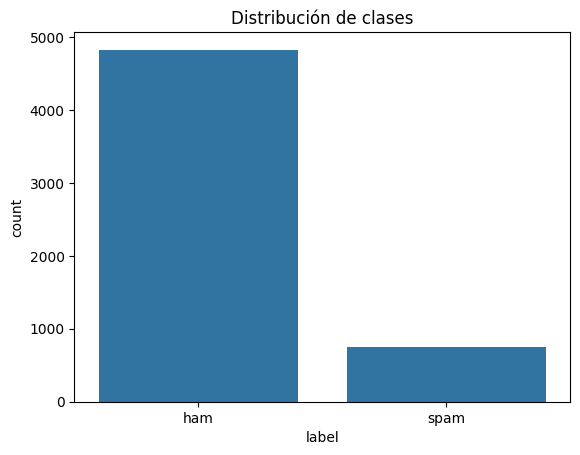

In [8]:

sns.countplot(x=df["label"])
plt.title("Distribución de clases")
plt.show()



# Longitud de mensajes

Los mensajes pueden tener longitudes muy diferentes.

Esto es importante porque:

- documentos largos tienen más palabras
- documentos cortos tienen menos información


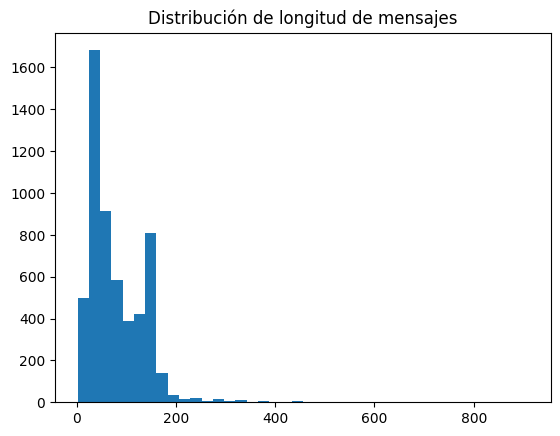

In [9]:

df["length"] = df["text"].apply(len)

plt.hist(df["length"], bins=40)
plt.title("Distribución de longitud de mensajes")
plt.show()



# Limpieza de texto

Problemas comunes en texto:

- mayúsculas
- puntuación
- símbolos
- ruido

Ejemplo:

"WIN MONEY NOW!!!"

Después de limpiar:

"win money now"


In [10]:

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)

df.head()


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,text,length,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though



# WordCloud

Un WordCloud permite visualizar las palabras más frecuentes.


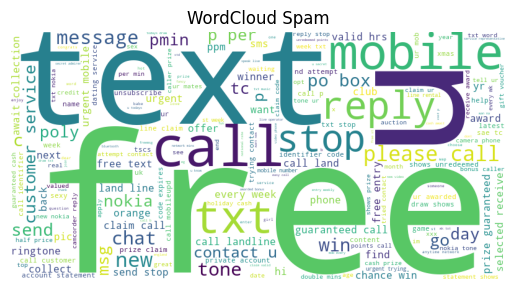

In [11]:

spam_words = " ".join(df[df["label"]=="spam"]["clean_text"])

wc = WordCloud(width=800,height=400,background_color="white").generate(spam_words)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud Spam")
plt.show()



# Codificación de etiquetas

Los modelos necesitan números.


In [12]:

df["label_num"] = df["label"].map({"ham":0,"spam":1})



**Bag of Words (BoW)** es una técnica básica de representación de texto en **Natural Language Processing (NLP)**.

La idea principal es representar un documento como un **vector numérico basado en la frecuencia de palabras**, ignorando el orden en que aparecen.

El término *bag* (bolsa) se usa porque el modelo trata el texto como un **conjunto de palabras sin considerar su estructura gramatical o posición**.



Ejemplo:

Documento 1: "I love ML"

Documento 2: "I love AI"

Vocabulario:

[I, love, ML, AI]

Representación:

Doc1 → [1,1,1,0]

Doc2 → [1,1,0,1]


# Idea central

El modelo Bag of Words funciona en tres pasos:

1. Construir un **vocabulario** con todas las palabras del corpus.
2. Contar cuántas veces aparece cada palabra en cada documento.
3. Representar cada documento como un **vector de frecuencias**.



In [13]:

bow = CountVectorizer(max_features=3000)

X_bow = bow.fit_transform(df["clean_text"])

X_bow.shape


(5572, 3000)


# TF‑IDF

TF‑IDF mejora Bag of Words.

La idea:

Una palabra es importante si:

- aparece mucho en un documento
- aparece poco en otros documentos

Formula:

TFIDF = TF × IDF


# TF–IDF (Term Frequency – Inverse Document Frequency)

TF–IDF es una técnica clásica de **representación de texto en NLP** que mide la importancia de una palabra dentro de un documento considerando todo el corpus.

La idea central es:

- **TF (Term Frequency)** mide qué tan frecuente es una palabra en un documento.
- **IDF (Inverse Document Frequency)** mide qué tan rara es esa palabra en todo el corpus.

El peso final de una palabra se obtiene combinando ambas métricas.



# Term Frequency (TF)

La **frecuencia de término (TF)** mide cuántas veces aparece un término en un documento.

## Fórmula

$$
TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
$$

donde:

- $t$ = término (palabra)  
- $d$ = documento  
- $f_{t,d}$ = número de veces que el término $t$ aparece en el documento $d$  
- $\sum_{t' \in d} f_{t',d}$ = número total de palabras en el documento  



In [14]:

tfidf = TfidfVectorizer(max_features=3000)

X_tfidf = tfidf.fit_transform(df["clean_text"])


In [44]:
X_tfidf 


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39471 stored elements and shape (5572, 3000)>


# Train Test Split


In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["label_num"],
    test_size=0.2,
    random_state=42
)



# Modelo de clasificación


In [16]:

model = LogisticRegression()

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


# Evaluación del modelo


In [17]:

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115




# Matriz de confusión


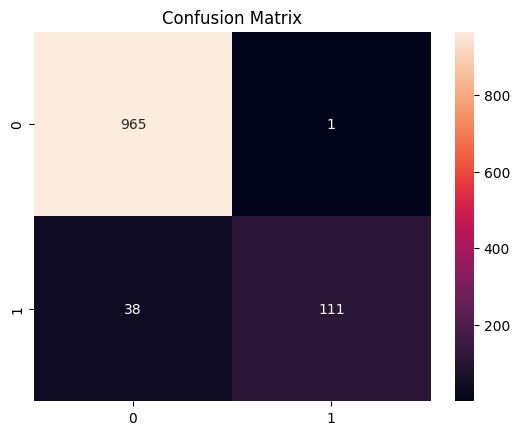

In [18]:

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()



# Visualización del espacio TF‑IDF con PCA

Cada documento es un vector de alta dimensión.

PCA permite reducirlo a 2 dimensiones.


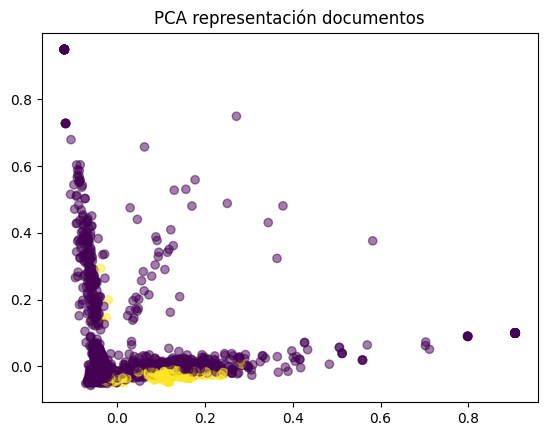

In [46]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_tfidf.toarray())

plt.scatter(X_pca[:,0],X_pca[:,1],c=df["label_num"],alpha=0.5)

plt.title("PCA representación documentos")

plt.show()



# Visualización con t‑SNE

t‑SNE es una técnica no lineal de reducción de dimensionalidad que preserva mejor los clusters.


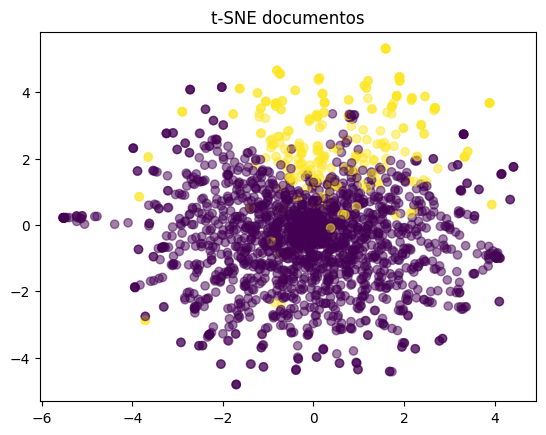

In [20]:

tsne = TSNE(n_components=2,perplexity=30,random_state=42)

X_tsne = tsne.fit_transform(X_tfidf.toarray()[:2000])

plt.scatter(X_tsne[:,0],X_tsne[:,1],c=df["label_num"][:2000],alpha=0.5)

plt.title("t-SNE documentos")

plt.show()



# Testeo


In [57]:

def predict_sms(text):

    clean = clean_text(text)

    vec = tfidf.transform([clean])

    pred = model.predict(vec)[0]

    if pred==1:
        return "SPAM"
    else:
        return "HAM"

predict_sms("Free pass y in 10 a wkly comp to win FA")


'SPAM'